In [1]:
# using CMPSKit, Plots, LaTeXStrings, OptimKit, KrylovKit, LinearAlgebra
using CMPSExcitations

In [2]:
# Local densities:
n̂ = ψ̂' * ψ̂; # particle density operator
k̂ = ∂ψ̂' * ∂ψ̂; # kinetic energy density operator
û = (ψ̂')^2 * ψ̂^2; # interaction operator

H(; c, μ) = ∫(k̂ - μ * n̂ + c * û, (-Inf, +Inf));

In [3]:
c, μ = 2., 50.
tol = 1e-10
hamiltonian = H(c=c, μ=μ)
hamiltonian_density = CMPSKit.density(hamiltonian)

Ds = [8]
state = find_groundstate(Ds, hamiltonian, InfiniteCMPS, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
D = maximum(Ds)
state.Rs[1][] ./= (state.Rs[1][][1] / norm(state.Rs[1][][1])) # fix phase
ρ = expval(n̂, state)[]

println("Energy density: ", expval(hamiltonian_density, state)[], "\n Particle density: ", expval(n̂, state)[], "\n Order parameter: ", expval(ψ̂, state)[])

println("LL parameter: ", c / ρ)

Optimizing D=8


┌ Warning: The function `inner` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Constant{Matrix{Float64}}}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface C:\Users\saksh\.julia\packages\VectorInterface\J6qCR\src\fallbacks.jl:196
┌ Warning: The function `scale` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Float64}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface C:\Users\saksh\.julia\packages\VectorInterface\J6qCR\src\fallbacks.jl:67
┌ Warning: The function `add!!` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Constant{Matrix{Float64}}, Float64, VectorInterface.One}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface C:\Users\saksh\.julia\packages\VectorInterface\J6qCR\src\fallbacks.jl:163
┌ Warning: The function `scalartype` is not implemented for (values of) type `Constant

D = 8 | InfiniteCMPS{Constant{Matrix{Float64}}, 1}
 54.213992 seconds (53.34 M allocations: 2.757 GiB, 1.41% gc time, 75.35% compilation time: <1% of which was recompilation)
---------------


┌ Info: UniformCMPS ground state: converged after 360 iterations: e = -367.174245928307, ‖∇e‖ = 6.6166e-11
└ @ CMPSKit C:\Users\saksh\Documents\PhDstuff\code\TensorNetworks\CMPSKit.jl\src\infinitecmps\groundstate.jl:127


Energy density: -367.17424592831
 Particle density: 14.123431048508422
 Order parameter: 3.4575764365370167
LL parameter: 0.14160864970634882


In [92]:
nvals = 10
pts = range(-2π * ρ, 2π * ρ, 31)
topological_spectrum = zeros(ComplexF64, length(pts), nvals);
topological_excitations = [[zeros(ComplexF64, size(state.Q[])) for _ in 1:nvals] for _ in eachindex(pts)]
u1charges = zeros(ComplexF64, length(pts), nvals)

ρr = rightenv(state)[1][]
theta = π
state = InfiniteCMPS(Constant(ComplexF64.(state.Q[])), Constant(ComplexF64.(state.Rs[1][])))
state_alt = InfiniteCMPS(state.Q, exp(1im * theta) * state.Rs[1])

Threads.@threads for idx in eachindex(pts)
    space = InfiniteCMPSExcitationSpace(pts[idx], state, state_alt)
    Heff = excitation_operator(hamiltonian, space)
    vals, vecs, _ = eigsolve(Heff, (Constant(rand(ComplexF64, size(state.Q[]))),), nvals, :SR)
    topological_spectrum[idx, :] .= vals[1:nvals]
    topological_excitations[idx] .= getindex.(getindex.(vecs[1:nvals], 1))

    for (i, W) in enumerate(topological_excitations[idx])
        # ∫⟨ρ⟩ - ⟨ρ₀⟩ = N -> particle/hole charge
        Hψ = excitation_operator(∫(ψ̂' * ψ̂, (-Inf, Inf)), space)
        ψW = Hψ((Constant(W),))[1][]
        u1charges[idx, i] = tr(ψW * ρr * W')
    end
    # println("Finished $idx - $(pts[idx])")
end

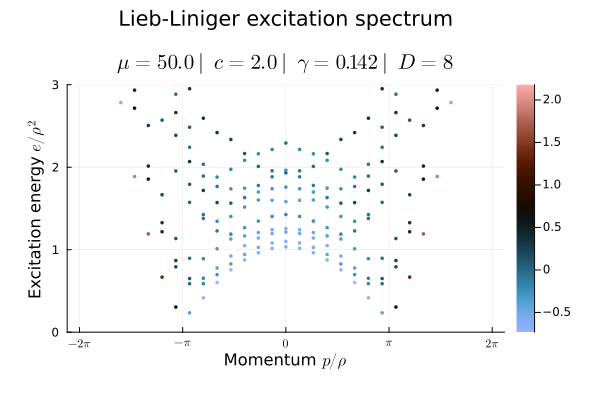

In [93]:
scatter(pts ./ ρ, real.(topological_spectrum) ./ ρ^2, ylims=[0, 3], lab=permutedims([""; fill("", nvals - 1)]), ms=2., marker_z=real.(u1charges), markerstrokewidth=0, colorbar=true, c=:berlin)
plot!(xtick=pitick(-2π, 2π, 1, mode=:latex), ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", title="Lieb-Liniger excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ c=%$(c) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins=7Plots.mm)

In [75]:
using OrdinaryDiffEq

In [77]:
function apply_expT(Q, R, ρ₀, xi, xf; side=:R)
    if side == :R
        function dρRdx!(dρR, ρR, (Q, R), x)
            dρR .= (Q * ρR + ρR * Q' + R * ρR * R')
        end

        prob = ODEProblem(dρRdx!, ρ₀, (xi, xf), (Q, R))
        return solve(prob, Tsit5())

    elseif side == :L
        function dρLdx!(dρL, ρL, (Q, R), x)
            dρL .= (ρL * Q + Q' * ρL + R' * ρL * R)
        end

        prob = ODEProblem(dρLdx!, ρ₀, (xi, xf), (Q, R))
        return solve(prob)
    else
        throw(DomainError(side, "Side must be either :L or :R."))
    end
end

function soliton_density(stateL, stateR, W, dist, x, N)
    yleft = range(x - dist, x, N)
    yright = range(x, x + dist, N)

    ρLl₀, ρRl₀, _, _ = environments!(stateL)
    ρLr₀, ρRr₀, _, _ = environments!(stateR)

    Ql, Rl = stateL.Q[], stateL.Rs[1][]
    Qr, Rr = stateR.Q[], stateR.Rs[1][]

    ρRs = apply_expT(Ql, Rl, W * ρRr₀[] * W', 0.0, dist, side=:R).(x .- yleft)
    densities = tr.(ρLl₀[] * Rl * ρR * Rl' for ρR in ρRs)

    ρRs = apply_expT(Qr, Rr, Rr * ρRr₀[] * Rr', 0.0, dist, side=:R).(yright .- x)
    append!(densities, tr.(ρLl₀[] * W * ρR * W' for ρR in ρRs))

    return vcat(yleft..., yright...), densities
end

soliton_density (generic function with 1 method)

  0.052748 seconds (10.15 k allocations: 4.669 MiB)


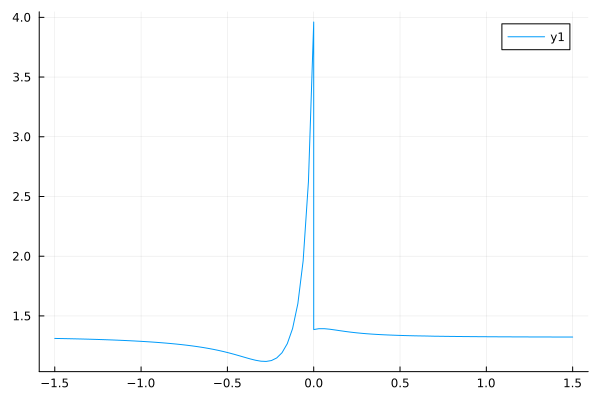

In [79]:
@time xs1, densities1 = soliton_density(state, state_alt, topological_excitations[10][1], 1.5, 0., 50)
plot(xs1, real.(densities1))

  0.060019 seconds (10.97 k allocations: 4.634 MiB, 13.42% compilation time)


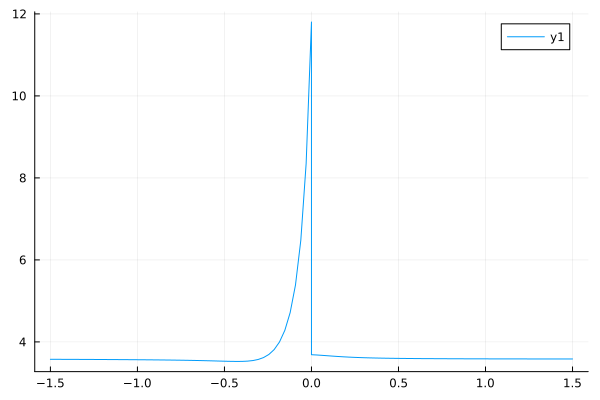

In [80]:
@time xs2, densities2 = soliton_density(state, state_alt, topological_excitations[end][1], 1.5, 0., 50)
plot(xs2, real.(densities2))